# MMELON Model Inference

Run inference with a finetuned MMELON model on **any CSV file** containing SMILES strings.

## Steps
0. Configuration — edit paths here
1. Preview input data
2. Load model
3. Build DataLoader
4. Run inference
5. Inspect predictions
6. Evaluate (if labels available)
7. Enrichment metrics (Precision@K / EF@K)
8. Top hits

In [3]:
def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False
IN_COLAB = in_colab()
print(f"{IN_COLAB=}")   

IN_COLAB=False


In [4]:
## installation in local env
# conda create -n mmelon311 python=3.11 -y
# conda activate mmelon311
# git clone https://github.com/jmorrone/biomed-multi-view.git
# pip install git+https://github.com/jmorrone/biomed-multi-view.git
# pip install --index-url https://download.pytorch.org/whl/cu121 torch==2.1.0 torchvision==0.16.0
# pip install --index-url https://download.pytorch.org/whl/cu121 "torch==2.1.0+cu121" "torchvision==0.16.0+cu121" --upgrade-strategy only-if-needed
# pip install -f https://data.pyg.org/whl/torch-2.1.0+cu121.html "pyg_lib==0.4.0+pt21cu121" "torch_scatter==2.1.2+pt21cu121" "torch_cluster==1.6.3+pt21cu121" "torch_spline_conv==1.2.2+pt21cu121" --upgrade-strategy only-if-needed
# pip install -q notebook ipykernel

In [5]:
if IN_COLAB:
    print("***** select runtime 2025.07!!!")

In [6]:
if IN_COLAB:
    !git clone https://github.com/jmorrone/biomed-multi-view.git

In [7]:
if IN_COLAB:
    !pip install git+https://github.com/jmorrone/biomed-multi-view.git  

In [8]:
if IN_COLAB:
    import os
    os.chdir('biomed-multi-view')
    !pip install -r requirements.txt

## 0. Configuration

**Edit the paths below before running.**

In [9]:
import os
import torch
run_on_wdr91 = False

model_name = "mmelon" # "mammal"
USER=os.environ["USER"]
if run_on_wdr91:
    # set inference model
    if model_name == "mmelon":
        # MODEL_PATH = "/proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mmelon_10_seed1234/last-v3.ckpt"
        MODEL_PATH = "michalozeryflato/biomed.sm.mv-te-84m.wdr91_asms"
    else:
        # MODEL_PATH = "/proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal_fixed/last.ckpt"
        MODEL_PATH = "michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.wdr91_asms"

    # set datapath
    if IN_COLAB:
        DATA_PATH = "/content/wdr91_test.csv"
        OUTPUT_PATH = f"/content/results/wdr91_{model_name}_predictions.csv"
    else:
        DATA_PATH = "/proj/ligand_ai/datasets_manager/processed/splits/wdr91_ASMS_train_val_v1/test.csv"
        USER = os.getenv("USER")
        OUTPUT_PATH = f"/proj/ligand_ai/users/{USER}/wdr91_{model_name}_predictions.csv"
else:
    if model_name == "mmelon":
        MODEL_PATH = "/proj/ligand_ai/models/PGK2_DEL_cdd_to_creative/mmelon_50/last.ckpt"
        # MODEL_PATH="michalozeryflato/biomed.sm.mv-te-84m.pgk2_del_cdd"
    else:
        # MODEL_PATH = "/proj/ligand_ai/models/PGK2_DEL_cdd_to_creative_mammal/last-v2.ckpt"
        MODEL_PATH = "michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.pgk2_del_cdd"

    if IN_COLAB:
        DATA_PATH = "/content/del_creative.csv"
        OUTPUT_PATH = f"/content/results/pgk2_{model_name}_predictions.csv"
    else:
        DATA_PATH = "/proj/ligand_ai/datasets_manager/processed/splits/PGK2_DEL_cdd_to_creative/test.csv"
        OUTPUT_PATH = f"/proj/ligand_ai/users/{USER}/pgk2_{model_name}_predictions.csv"

DATA_DIR_FOR_MMELON =None if IN_COLAB else f"/proj/ligand_ai/users/{USER}/"
# Column names
SMILES_COLUMN = "smiles"
LABEL_COLUMN = "label"

assert os.path.exists(DATA_PATH),  f"Data not found:  {DATA_PATH}"
os.makedirs(os.path.dirname(OUTPUT_PATH) or ".", exist_ok=True)

# Inference settings
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"{MODEL_PATH=}")
print(f"{DATA_PATH=}")
print(f"{OUTPUT_PATH=}")
print(f"{DEVICE=}")

MODEL_PATH='/proj/ligand_ai/models/PGK2_DEL_cdd_to_creative/mmelon_50/last.ckpt'
DATA_PATH='/proj/ligand_ai/datasets_manager/processed/splits/PGK2_DEL_cdd_to_creative/test.csv'
OUTPUT_PATH='/proj/ligand_ai/users/ozery/pgk2_mmelon_predictions.csv'
DEVICE='cuda'


## 1. Preview Input Data

In [10]:
import pandas as pd

input_df = pd.read_csv(DATA_PATH)
input_df["sample_id"] = input_df.index.astype(str)  # Add sample_id column based on index
display(input_df)

,smiles,label,sample_id
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0,0
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0,1
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0,2
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0,3
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1,4
...,...,...,...
14743,CNC(=O)C[C@@H](Cc1ccccc1)n1c(-c2ccc3c(c2)oc(=O...,0,14743
14744,CNC(=O)C[C@H](c1ccccc1)n1c(C2CCCCC2C)nc2cc(CNC...,0,14744
14745,CO[C@@]1(C)CCN(C(=O)[C@H]2CC[C@H](CN(CC(=O)O)C...,0,14745
14746,Cc1ccc(N)cc1CN(C)C(=O)C1(c2cccc(C(=O)NCCCn3ccn...,1,14746


## 2. Load Model

In [11]:
from bmfm_sm.predictive.modules.finetune_lightning_module import FineTuneLightningModule
model = FineTuneLightningModule.load_from_checkpoint(
        MODEL_PATH, 
        map_location=DEVICE
    )
model.to(DEVICE)

/proj/bmfm/users/ozery/miniforge3/envs/mmelon311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-08 12:55:14,727 - root - INFO - maggie:23370543601472:0:0 - Initializing model with params {'agg_arch': 'coeff_mlp', 'agg_gate_input': 'coeff_mlp', 'agg_weight_freeze': None, 'inference_mode': False}
2026-03-08 12:55:18,691 - rdkit - INFO - maggie:23370543601472:0:0 - Enabling RDKit 2022.09.5 jupyter extensions
/proj/bmfm/users/ozery/miniforge3/envs/mmelon311/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/proj/bmfm/users/ozery/miniforge3/envs/mmelon311/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments oth

FineTuneLightningModule(
  (model): SmallMoleculeMultiView(
    (model_graph): Graph2dModel(
      (graph_encoder): Graph2dEncoder(
        (dropout_module): Dropout(p=0.0, inplace=False)
        (graph_feature): GraphFeatureTokenizer(
          (atom_encoder): Embedding(4608, 512, padding_idx=0)
          (edge_encoder): Embedding(1536, 512, padding_idx=0)
          (graph_token): Embedding(1, 512)
          (null_token): Embedding(1, 512)
          (lap_encoder): Linear(in_features=32, out_features=512, bias=False)
          (lap_eig_dropout): Dropout2d(p=0.2, inplace=False)
          (order_encoder): Embedding(2, 512)
        )
        (emb_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (final_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (layers): ModuleList(
          (0-11): 12 x Graph2dEncoderLayer(
            (dropout_module): Dropout(p=0.0, inplace=False)
            (self_attn): MultiheadAttention(
              (atten

## 3. Build DataLoader

In [12]:
import os
import shutil
from torch.utils.data import DataLoader
from bmfm_sm.predictive.data_modules.multimodal_finetune_dataset import MultiModalFinetuneDataPipeline
from bmfm_sm.core.data_modules.namespace import TaskType

def create_dataloader(
    csv_path: str,
    smiles_column: str = 'smiles',
    label_column: str = 'label',
    batch_size: int = 32,
    num_workers: int = 0,  # Set to 0 to avoid multiprocessing issues in notebooks
    data_dir: str = None,
):
    print(f"Creating DataLoader from: {csv_path}")

    # Get the directory containing the CSV file
    data_dir = data_dir or os.path.dirname(csv_path)
    predict_csv = os.path.join(data_dir, 'data_predict.csv')
    shutil.copy(csv_path, predict_csv)

    # Dataset arguments for MMELON framework (matching evaluate_mmelon.py lines 448-455)
    dataset_args = {
        'task_type': TaskType.CLASSIFICATION,
        'num_tasks': 1,
        'modalities': ['TEXT_MODEL', 'IMAGE_MODEL', 'GRAPH_2D_MODEL'],
        'smiles_col': smiles_column,
        'label_cols': [label_column],
        'split_col': None
    }
    
    # Create dataset (matching evaluate_mmelon.py lines 458-462)
    dataset = MultiModalFinetuneDataPipeline(
        data_dir=data_dir,
        dataset_args=dataset_args,
        stage='predict'  # Use 'predict' stage like evaluate_mmelon.py
    )

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=dataset.collate_fn
    )
        
    return dataloader

In [13]:
dataloader = create_dataloader(
    csv_path=DATA_PATH,
    smiles_column=SMILES_COLUMN,
    label_column=LABEL_COLUMN,
    batch_size= 32, #128, #32
    num_workers=4,
    data_dir=DATA_DIR_FOR_MMELON,
)

Creating DataLoader from: /proj/ligand_ai/datasets_manager/processed/splits/PGK2_DEL_cdd_to_creative/test.csv


2026-03-08 12:55:21,149 - root - INFO - maggie:23370543601472:0:0 - Working on task TaskType.CLASSIFICATION
2026-03-08 12:55:21,150 - root - INFO - maggie:23370543601472:0:0 - modalities running in data pipeline TEXT_MODEL,IMAGE_MODEL,GRAPH_2D_MODEL


In [14]:
## inspect first batch
first_batch = next(iter(dataloader))
for k,v in first_batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {type(v)=} {v.shape=}")
    else:
        print(f"{k}: {type(v)=} {len(v)=}")

img: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([32, 3, 224, 224])
label: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([32, 1])
smiles.tokenized: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([32, 106])
attention_mask: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([32, 106])
node_num: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([32])
node_data: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([1465, 9])
edge_num: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([32])
edge_data: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([3210, 5])
edge_index: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([2, 3210])
lap_eigvec: type(v)=<class 'torch.Tensor'> v.shape=torch.Size([1465, 61])


## 4. Run Inference

In [15]:
import numpy as np
from tqdm import tqdm
def run_inference(
    model,
    dataloader: DataLoader,
    device: str = 'cuda',
) -> pd.DataFrame:
    
    all_preds = []
    all_probs = []
    
    model.eval()
    batch_count = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="batches"):
            # Move batch to device
            for key in batch:
                if isinstance(batch[key], torch.Tensor):
                    batch[key] = batch[key].to(device)
            
            # Forward pass - use forward0 to get embeddings (same as evaluate_mmelon.py line 486)
            embeddings = model.model.forward0(batch)
            if isinstance(embeddings, tuple):
                embeddings = embeddings[0]  # Extract embeddings from tuple
            
            # Apply prediction head (same as evaluate_mmelon.py line 491)
            logits = model.pred_head(embeddings)
            
            # Squeeze extra dimensions if present
            if logits.dim() > 2:
                logits = logits.squeeze(-1)
            
            # Get probabilities - use sigmoid for binary classification (line 494)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probs.append(probs)
            all_preds.append(preds)
            batch_count += 1
    
    # Concatenate and flatten (same as evaluate_mmelon.py lines 500-501)
    probabilities = np.vstack(all_probs).flatten()
    predictions = np.vstack(all_preds).flatten()
    
    return pd.DataFrame({"predicted_label": predictions, "prediction_score": probabilities})

In [16]:
%%time
predictions_df = run_inference(model, dataloader, device=DEVICE)
display(predictions_df)

2026-03-08 12:55:23,216 - root - INFO - maggie:23370543601472:0:0 - in train False setting deterministic_eval = True
batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 461/461 [00:43<00:00, 10.59it/s]


,predicted_label,prediction_score
0,0,0.000213
1,0,0.000236
2,0,0.000248
3,0,0.009336
4,1,0.999290
...,...,...
14743,0,0.000256
14744,0,0.000209
14745,0,0.000197
14746,0,0.001015


CPU times: user 37 s, sys: 4.01 s, total: 41 s
Wall time: 43.5 s


In [17]:
predictions_df.to_csv(OUTPUT_PATH, index=False)
print("wrote", OUTPUT_PATH)

wrote /proj/ligand_ai/users/ozery/pgk2_mmelon_predictions.csv


## 5. Inspect Predictions

In [18]:
predictions_df = pd.concat([input_df, predictions_df], axis=1)

In [19]:
predictions_df = predictions_df.rename(columns={LABEL_COLUMN: "true_label" })
display(predictions_df)

,smiles,true_label,sample_id,predicted_label,prediction_score
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0,0,0,0.000213
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0,1,0,0.000236
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0,2,0,0.000248
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0,3,0,0.009336
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1,4,1,0.999290
...,...,...,...,...,...
14743,CNC(=O)C[C@@H](Cc1ccccc1)n1c(-c2ccc3c(c2)oc(=O...,0,14743,0,0.000256
14744,CNC(=O)C[C@H](c1ccccc1)n1c(C2CCCCC2C)nc2cc(CNC...,0,14744,0,0.000209
14745,CO[C@@]1(C)CCN(C(=O)[C@H]2CC[C@H](CN(CC(=O)O)C...,0,14745,0,0.000197
14746,Cc1ccc(N)cc1CN(C)C(=O)C1(c2cccc(C(=O)NCCCn3ccn...,1,14746,0,0.001015


In [20]:
print(f"Shape: {predictions_df.shape}")
print(f"\nPredicted label distribution:")
print(predictions_df["predicted_label"].value_counts().sort_index())
print(f"\nScore statistics:")
print(predictions_df["prediction_score"].describe())

Shape: (14748, 5)

Predicted label distribution:
predicted_label
0    13491
1     1257
Name: count, dtype: int64

Score statistics:
count    14748.000000
mean         0.086594
std          0.274475
min          0.000194
25%          0.000209
50%          0.000225
75%          0.000317
max          0.999332
Name: prediction_score, dtype: float64


## 6. Evaluate (if labels available)

CLASSIFICATION METRICS
Accuracy  : 0.9763
Precision : 0.9451
Recall    : 0.8093
F1 Score  : 0.8719
ROC AUC   : 0.9043
PR AUC    : 0.8583


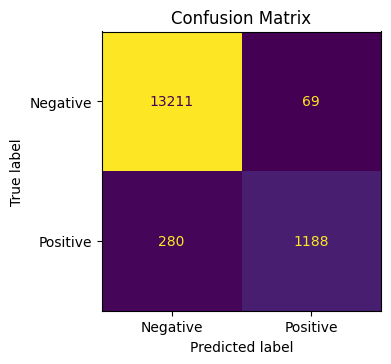

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

has_labels = predictions_df["true_label"].notna().any()

if has_labels:
    valid   = predictions_df[predictions_df["true_label"].notna()].copy()
    y_true  = valid["true_label"].astype(int)
    y_pred  = valid["predicted_label"].astype(int)
    y_score = valid["prediction_score"].astype(float)

    print("=" * 50)
    print("CLASSIFICATION METRICS")
    print("=" * 50)
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC AUC   : {roc_auc_score(y_true, y_score):.4f}")
    print(f"PR AUC    : {average_precision_score(y_true, y_score):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("No true labels found — skipping evaluation.")

## 7. Enrichment Metrics (Precision@K / EF@K)

In [22]:
def calculate_enrichment_metrics(
    y_true,
    y_scores,
    top_k_values: list[int] | None = None,
) -> dict:
    if top_k_values is None:
        top_k_values = [10, 50, 100, 500, 1000, 2000]

    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    sorted_indices = np.argsort(y_scores)[::-1]
    sorted_labels = y_true[sorted_indices]

    hit_prevalence = np.sum(y_true) / len(y_true)

    enrichment: dict = {}
    for k in top_k_values:
        if k <= len(sorted_labels):
            top_k_labels = sorted_labels[:k]
            precision_at_k = np.sum(top_k_labels) / k
            enrichment[f"Precision@{k}"] = precision_at_k
            enrichment[f"EF@{k}"] = (
                precision_at_k / hit_prevalence if hit_prevalence > 0 else np.nan
            )
        else:
            enrichment[f"Precision@{k}"] = np.nan
            enrichment[f"EF@{k}"] = np.nan

    return enrichment

In [23]:
import numpy as np

n_total = len(valid)
top_k_values = sorted({k for k in [10, 50, 100, 500, 1000, 2000] if k <= n_total})
if n_total not in top_k_values:
    top_k_values.append(n_total)

enrichment = calculate_enrichment_metrics(
    y_true.values, y_score.values, top_k_values=top_k_values
)

n_positives = int(y_true.sum())
hit_prev    = n_positives / n_total

print("=" * 60)
print("ENRICHMENT METRICS")
print("=" * 60)
print(f"Dataset : {n_total} compounds  |  Positives: {n_positives}  |  Hit rate: {hit_prev:.2%}")
print()
print(f"{'K':>8}  {'Precision@K':>12}  {'EF@K':>8}  {'Hits in top-K':>14}")
print("-" * 50)
for k in top_k_values:
    prec = enrichment.get(f"Precision@{k}", np.nan)
    ef   = enrichment.get(f"EF@{k}",        np.nan)
    hits = int(round(prec * k)) if not np.isnan(prec) else "N/A"
    print(f"{k:>8}  {prec:>12.4f}  {ef:>8.2f}  {hits:>14}")
print("=" * 60)

ef_rows = [
    {
        "K":             k,
        "Precision@K":   enrichment.get(f"Precision@{k}", np.nan),
        "EF@K":          enrichment.get(f"EF@{k}",        np.nan),
        "Hits_in_top_K": int(round(enrichment.get(f"Precision@{k}", 0) * k)),
    }
    for k in top_k_values
]
ef_df = pd.DataFrame(ef_rows)
ef_df


ENRICHMENT METRICS
Dataset : 14748 compounds  |  Positives: 1468  |  Hit rate: 9.95%

       K   Precision@K      EF@K   Hits in top-K
--------------------------------------------------
      10        1.0000     10.05              10
      50        1.0000     10.05              50
     100        1.0000     10.05             100
     500        0.9980     10.03             499
    1000        0.9950     10.00             995
    2000        0.6100      6.13            1220
   14748        0.0995      1.00            1468


,K,Precision@K,EF@K,Hits_in_top_K
0,10,1.000000,10.046322,10
1,50,1.000000,10.046322,50
2,100,1.000000,10.046322,100
3,500,0.998000,10.026229,499
4,1000,0.995000,9.996090,995
5,2000,0.610000,6.128256,1220
6,14748,0.099539,1.000000,1468


## 8. Top Hits

In [24]:
top_k = 10
top_predictions_df = (
    predictions_df
    .sort_values("prediction_score", ascending=False)
    .head(top_k)
    .reset_index(drop=True)
)

n_pos = (top_predictions_df["true_label"] == 1).sum()
print(f"Top {top_k} predicted positives (out of {n_pos} total predicted positives):")
display(top_predictions_df[["sample_id", SMILES_COLUMN, "prediction_score", "true_label"]])

Top 10 predicted positives (out of 10 total predicted positives):


,sample_id,smiles,prediction_score,true_label
0,12401,CNC(=O)CCC1CCN(C(=O)[C@H]2CC[C@H]2NC(=O)c2ccc3...,0.999332,1
1,6833,CNC(=O)CCC1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cn...,0.999331,1
2,7569,CNC(=O)C1CCC(NC(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc...,0.999329,1
3,6418,CCOC(=O)c1ccccc1-c1cccc([C@H]2CN(C(=O)c3cnc4[n...,0.999328,1
4,10375,CNC(=O)CCC1CCN(C(=O)[C@@H]2CN(C(=O)c3ccc4c(c3)...,0.999328,1
5,683,CCOC(=O)c1ccccc1-c1cccc([C@H]2CN(C(=O)c3cnc4[n...,0.999327,1
6,1721,CNC(=O)CCC1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cn...,0.999327,1
7,8999,CNC(=O)C1CCC(NC(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc...,0.999327,1
8,12736,CNC(=O)CCC1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cn...,0.999327,1
9,8797,CNC(=O)CC1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc...,0.999326,1
